In [58]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
id_list = [925, 165, 9, 477, 291, 162]

In [60]:
nr_of_seeds = 10 #nr of seeds in the experiments
index = 925

In [61]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [62]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [63]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_29996\3805261461.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_29996\3805261461.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

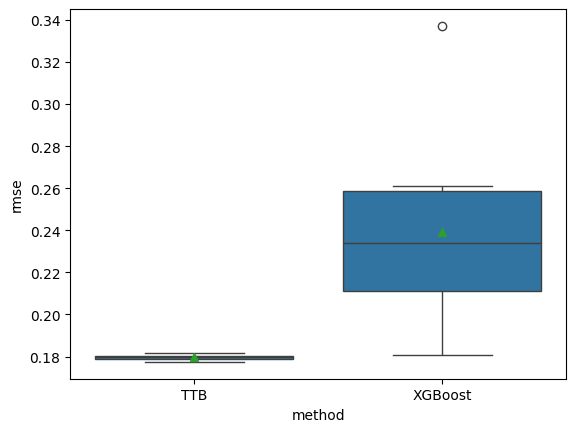

In [64]:


dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [65]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
3,0.1,1.0,1.0,0.01,0.5,0.177445,1,860.0,400.0,0.217562,0.161072,0.177445,0.141683,TransferTreeBoost
1,0.1,1.0,1.0,0.00,0.5,0.178349,1,860.0,400.0,0.219942,0.164474,0.178349,0.143873,TransferTreeBoost
31,0.1,2.0,1.0,0.05,0.9,0.179038,1,860.0,400.0,0.219718,0.165868,0.179038,0.143453,TransferTreeBoost
7,0.1,1.0,1.0,0.05,0.9,0.179143,1,860.0,400.0,0.219051,0.162908,0.179143,0.141921,TransferTreeBoost
6,0.1,1.0,1.0,0.05,0.5,0.179346,1,860.0,400.0,0.220297,0.160677,0.179346,0.141492,TransferTreeBoost
25,0.1,2.0,1.0,0.00,0.5,0.179902,1,860.0,400.0,0.221669,0.166917,0.179902,0.145535,TransferTreeBoost
27,0.1,2.0,1.0,0.01,0.5,0.180191,1,860.0,400.0,0.219759,0.165091,0.180191,0.145688,TransferTreeBoost
49,0.1,3.0,1.0,0.00,0.5,0.180285,1,860.0,400.0,0.211111,0.158167,0.180285,0.144661,TransferTreeBoost
55,0.1,3.0,1.0,0.05,0.9,0.181104,1,860.0,400.0,0.212360,0.158789,0.181104,0.144174,TransferTreeBoost
30,0.1,2.0,1.0,0.05,0.5,0.181579,1,860.0,400.0,0.219776,0.162086,0.181579,0.145305,TransferTreeBoost


In [66]:
lk

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2,0.1,3.0,0.232483,30,2,860.0,0.211967,0.153791,0.180548,0.145946,XGBoost
8,0.1,3.0,0.232483,30,8,861.0,0.206670,0.162347,0.248492,0.186959,XGBoost
14,0.1,3.0,0.232483,30,14,862.0,0.238602,0.175117,0.209111,0.163749,XGBoost
20,0.1,3.0,0.232483,30,20,863.0,0.237977,0.192668,0.256881,0.192018,XGBoost
26,0.1,3.0,0.232483,30,26,864.0,0.252270,0.181944,0.201966,0.159428,XGBoost
44,0.1,3.0,0.232483,30,44,867.0,0.212246,0.182243,0.217330,0.165943,XGBoost
38,0.1,3.0,0.232483,30,38,866.0,0.297017,0.205397,0.260906,0.183908,XGBoost
32,0.1,3.0,0.232483,30,32,865.0,0.247749,0.186103,0.259551,0.186235,XGBoost
50,0.1,3.0,0.232483,30,50,868.0,0.219405,0.161053,0.337132,0.226108,XGBoost
56,0.1,3.0,0.232483,30,56,869.0,0.217246,0.162530,0.219682,0.176334,XGBoost


In [67]:
jk

NameError: name 'jk' is not defined